# defer 延时执行节点


2026-07-21 08:39:23.543 | INFO     | __main__:audit_node:43 - 任务阶段已全部执行完毕，诗已生成， 笑话已生成


{'topic': '猫咪', 'poem': '## 《晨起遇猫》\n\n当第一缕光刺入\n你用爪印解开\n一夜麻线团\n\n水缸里，影的形态\n是尚未解开的短笺\n\n你在缸沿行走\n像句号在句末迟疑\n尾巴垂落时\n水痕圈起了\n半部未落款的天', 'joke': '# 一个关于猫咪的笑话\n\n有一天，一只猫走进了一家咖啡馆，跳上柜台对老板说：“我要一杯猫屎咖啡。”\n\n老板一脸震惊：“你……你会说话？！”\n\n猫淡定地舔了舔爪子：“当然会，不然你以为我每天‘喵喵’叫是在跟你打招呼？我是在点单好吗？只不过你们人类听力太差，翻译不出来。”\n\n老板缓了缓神，又问：“那你要猫屎咖啡？”\n\n猫翻了个白眼：“对啊，尝尝同行的作品，看看谁拉的豆子更香。”\n\n老板：“……那您需要加糖吗？”\n\n猫：“不用，我减肥。就给我配一小碟猫薄荷饼干就行。”'}


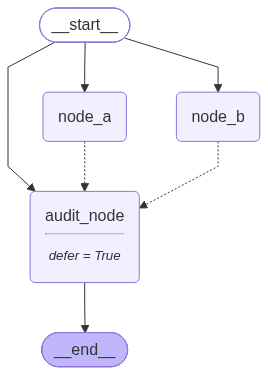

In [1]:
from langgraph.constants import START
from typing import TypedDict

from IPython.display import display
from dotenv import load_dotenv
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import StateGraph, END
from loguru import logger

load_dotenv(override=True)

# 获取模型
model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={"thinking": {"type": "disabled"}}
)


# 1、定义状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    content_type: str


# 2、定义节点
def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke(f"请写一个关于{state["topic"]}的诗").content
    return {
        "poem": poem
    }


def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke(f"请写一个关于{state["topic"]}的笑话").content
    return {
        "joke": joke
    }


def audit_node(state: OverAllState) -> OverAllState:
    logger.info(
        f"任务阶段已全部执行完毕，诗{'已生成' if state['poem'] else '未生成'}， 笑话{'已生成' if state['joke'] else '未生成'}")


# 3、构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node(node_a)
builder.add_node(node_b)
builder.add_node(audit_node, defer=True)
builder.add_edge(START, "node_a")
builder.add_edge(START, "node_b")
builder.add_edge(START, "audit_node")

builder.add_edge("node_a", END)
builder.add_edge("node_b", END)
builder.add_edge("audit_node", END)

graph = builder.compile()
poem_res = graph.invoke({"topic": "猫咪"})
print(poem_res)

display(graph)